# 🌱 Soil-Plant Physiological Coupling Analysis
### Machine Learning Panel Presentation

This notebook demonstrates the end-to-end data science pipeline for predicting yield loss based on real-time sensor data, with a specific focus on **microplastic contamination (represented by Turbidity)** and **crop health (Chlorophyll)**.

## 1. Environment Setup & Data Acquisition
Loading the core libraries and the dataset generated from the monitoring system.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Premium Styling Configuration
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams['figure.figsize'] = [12, 7]
plt.rcParams['font.size'] = 12

# Load Dataset
try:
    df = pd.read_csv('soil_plant_data.csv')
    print(f"✅ Successfully loaded {len(df)} monitoring samples.")
    display(df.head())
except FileNotFoundError:
    print("❌ Error: 'soil_plant_data.csv' not found. Please ensure data generation script has run.")

✅ Successfully loaded 1000 monitoring samples.


,temperature,humidity,soilMoisture,soilPH,chlorophyll,turbidity,yieldLoss
0,26.236204,42.033640,30.936455,7.363515,50.039711,39.363552,37.690819
1,43.521429,65.223562,29.758304,7.983407,66.380263,47.343566,44.631944
2,36.959818,86.741479,82.500366,5.252339,63.211265,85.454739,42.785137
3,32.959755,77.594618,29.963696,7.124370,20.772993,34.000439,53.230307
4,19.680559,82.426475,31.755978,6.858730,20.447463,86.964968,66.675361


## 2. Statistical EDA
Understanding the distribution and relationships between soil properties and plant yield.

📋 Feature Summary Statistics:


,temperature,humidity,soilMoisture,soilPH,chlorophyll,turbidity,yieldLoss
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,29.707697,62.956125,50.192458,6.451875,44.587373,49.846449,44.747782
std,8.764121,18.992343,23.253936,1.432447,20.076696,28.919481,13.276163
min,15.138961,30.209187,10.000931,4.003267,10.002150,0.618382,10.089031
25%,22.079198,45.669828,30.908078,5.209504,27.148180,24.938000,34.928023
50%,29.904221,63.717704,50.049114,6.421396,44.621867,49.040282,44.710339
75%,37.329588,79.430229,70.728282,7.687704,61.799542,73.985178,54.843062
max,44.991530,94.961892,89.825668,8.997789,79.842457,99.935030,77.651026


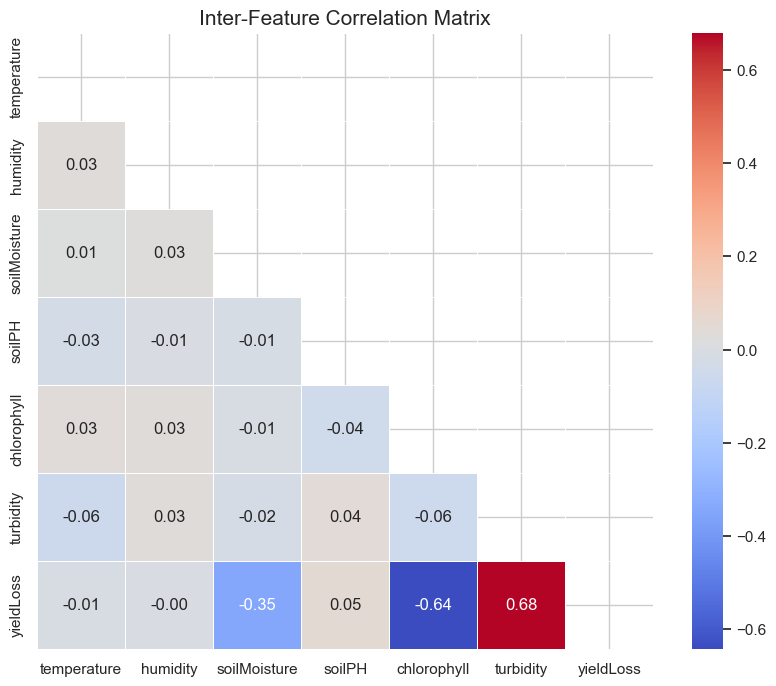

In [8]:
# Descriptive Statistics
print("📋 Feature Summary Statistics:")
display(df.describe())

# Correlation Heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=.5)
plt.title('Inter-Feature Correlation Matrix', fontsize=15)
plt.show()

## 3. Data Preprocessing & Model Architecture
Preparing the data for the Random Forest Regressor using scaling and splitting.

In [9]:
# Define Features (X) and Target (y)
features = ['temperature', 'humidity', 'soilMoisture', 'soilPH', 'chlorophyll', 'turbidity']
X = df[features]
y = df['yieldLoss']

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and Train Model
model = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
model.fit(X_train_scaled, y_train)

print("🚀 Machine Learning Model Trained Successfully.")

🚀 Machine Learning Model Trained Successfully.


## 4. Evaluation Metrics
Quantifying the model's accuracy on unseen testing data.

In [10]:
predictions = model.predict(X_test_scaled)
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print(f"📌 R-squared (Predictive Accuracy): {r2*100:.2f}%")
print(f"📌 Mean Absolute Error: {mae:.2f}%")
print(f"📌 Root Mean Squared Error: {rmse:.2f}%")

📌 R-squared (Predictive Accuracy): 92.22%
📌 Mean Absolute Error: 2.87%
📌 Root Mean Squared Error: 3.61%


## 5. Visual Insights & Importance
Identifying which parameters drive yield loss and validating prediction reliability.

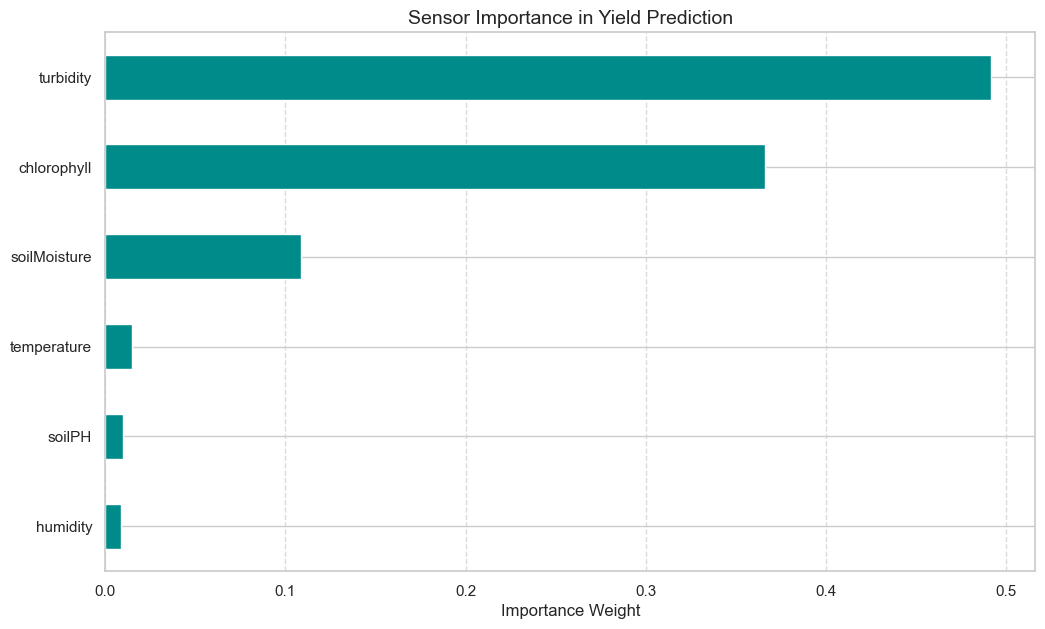


📈 Reliability Analysis: Joint Distribution of Predictions


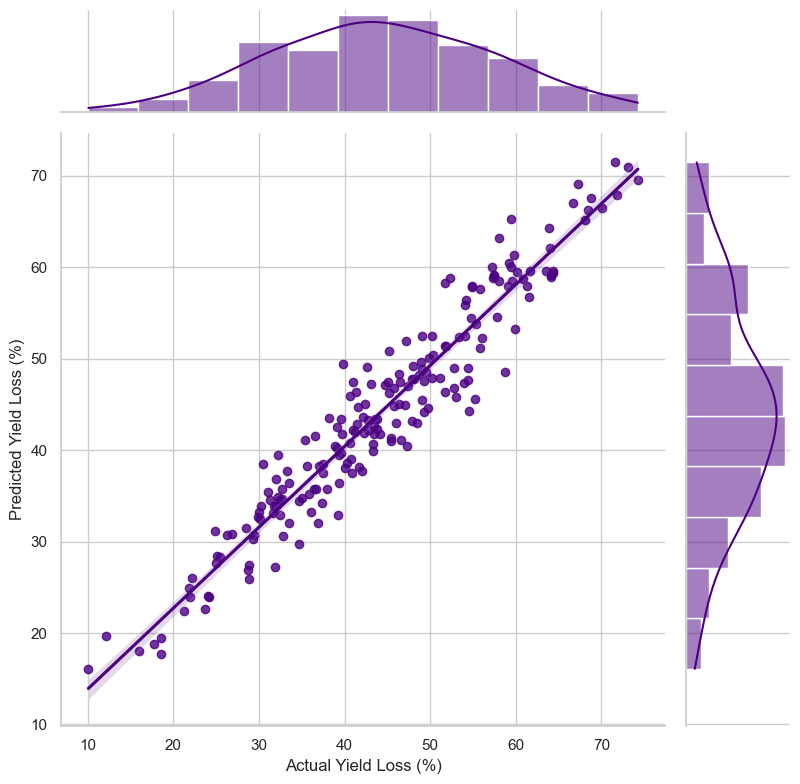

In [11]:
# 5.1 Feature Importance Plot
importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', color='darkcyan')
plt.title('Sensor Importance in Yield Prediction', fontsize=14)
plt.xlabel('Importance Weight')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 5.2 Reliability Plot (Actual vs Predicted)
print("\n📈 Reliability Analysis: Joint Distribution of Predictions")
sns.jointplot(x=y_test, y=predictions, kind='reg', color='indigo', height=8)
plt.xlabel('Actual Yield Loss (%)')
plt.ylabel('Predicted Yield Loss (%)')
plt.show()